# 01 · EDA & Imbalance Audit

Understand the Home Credit application data before modeling: quantify the class imbalance, map missing data, clean two known data issues, and check which features relate to default. Scope: `application_train.csv` only.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)

FIG_DIR = "../reports/figures"

app = pd.read_csv("../data/raw/application_train.csv")
print("Rows, columns:", app.shape)
app.head()

Rows, columns: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1 · Class imbalance

`TARGET = 1` means the applicant defaulted.

In [2]:
counts = app["TARGET"].value_counts().sort_index()
base_rate = app["TARGET"].mean()

print(counts)
print(f"\nDefault (base) rate: {base_rate:.2%}")
print(f"A model that predicts 'everyone repays' would be {1 - base_rate:.2%} accurate "
      f"-- and would approve every bad loan. That is why accuracy is useless here.")

TARGET
0    282686
1     24825
Name: count, dtype: int64

Default (base) rate: 8.07%
A model that predicts 'everyone repays' would be 91.93% accurate -- and would approve every bad loan. That is why accuracy is useless here.


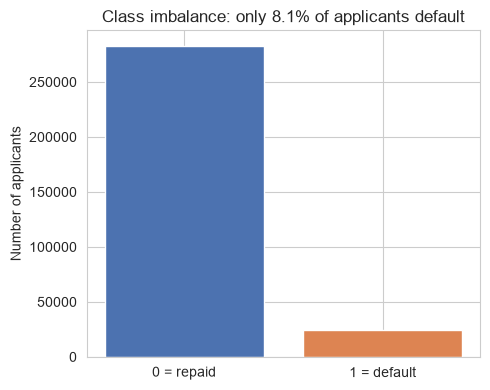

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["0 = repaid", "1 = default"], counts.values, color=["#4c72b0", "#dd8452"])
ax.set_ylabel("Number of applicants")
ax.set_title(f"Class imbalance: only {base_rate:.1%} of applicants default")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_class_imbalance.png", dpi=120)
plt.show()

## 2 · Missing data

In [4]:
missing = app.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"{len(missing)} of {app.shape[1]} columns have missing values.")
missing.head(10).round(3)

67 of 122 columns have missing values.


COMMONAREA_AVG              0.699
COMMONAREA_MODE             0.699
COMMONAREA_MEDI             0.699
NONLIVINGAPARTMENTS_MEDI    0.694
NONLIVINGAPARTMENTS_MODE    0.694
NONLIVINGAPARTMENTS_AVG     0.694
FONDKAPREMONT_MODE          0.684
LIVINGAPARTMENTS_AVG        0.684
LIVINGAPARTMENTS_MEDI       0.684
LIVINGAPARTMENTS_MODE       0.684
dtype: float64

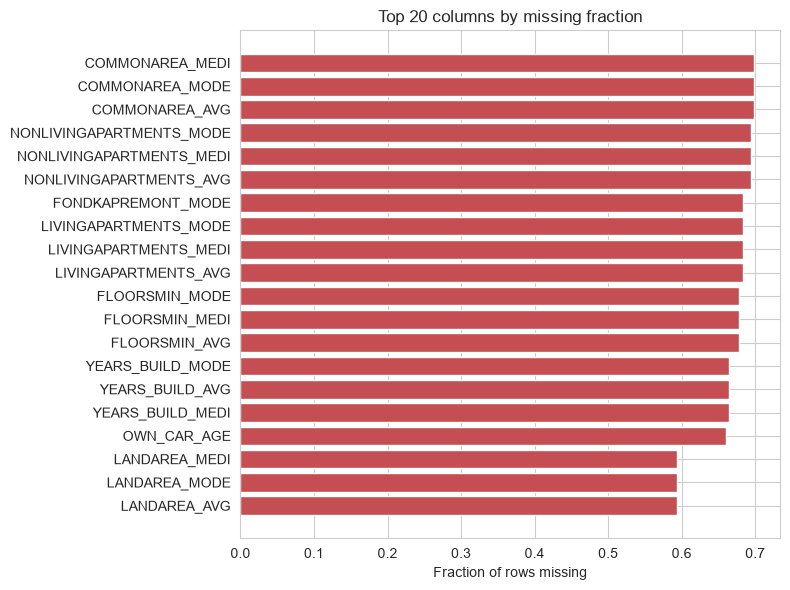

In [5]:
top_missing = missing.head(20).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_missing.index, top_missing.values, color="#c44e52")
ax.set_xlabel("Fraction of rows missing")
ax.set_title("Top 20 columns by missing fraction")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_missingness.png", dpi=120)
plt.show()

Most-missing columns are building details (~70% missing); the strong `EXT_SOURCE_*` predictors are far more complete. Tree models handle missing values, so nothing is dropped.

## 3 · Cleaning two data-quality issues

`DAYS_EMPLOYED` uses `365243` as a "not employed" code → replace with `NaN`. The negative `DAYS_*` columns are converted to positive years.

In [6]:
# (a) replace the "not employed" placeholder with NaN
print("Before cleaning, DAYS_EMPLOYED max:", app["DAYS_EMPLOYED"].max())
placeholder_share = (app["DAYS_EMPLOYED"] == 365243).mean()
print(f"Share of rows using the 365243 placeholder: {placeholder_share:.1%}")

app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

# (b) negative days -> positive years
app["AGE_YEARS"] = -app["DAYS_BIRTH"] / 365
app["YEARS_EMPLOYED"] = -app["DAYS_EMPLOYED"] / 365

app[["AGE_YEARS", "YEARS_EMPLOYED"]].describe().round(1)

Before cleaning, DAYS_EMPLOYED max: 365243
Share of rows using the 365243 placeholder: 18.0%


,AGE_YEARS,YEARS_EMPLOYED
count,307511.0,252137.0
mean,43.9,6.5
std,12.0,6.4
min,20.5,-0.0
25%,34.0,2.1
50%,43.2,4.5
75%,53.9,8.7
max,69.1,49.1


## 4 · Which features relate to default?

In [7]:
def default_rate_by_bin(frame, col, bins=10):
    """Split a numeric column into equal-sized bins and return the default rate in each."""
    binned = pd.qcut(frame[col], q=bins, duplicates="drop")
    return frame.groupby(binned, observed=True)["TARGET"].mean()

for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    rates = default_rate_by_bin(app.dropna(subset=[col]), col)
    print(f"{col}: lowest-score bin defaults {rates.iloc[0]:.1%}, "
          f"highest-score bin defaults {rates.iloc[-1]:.1%}")

EXT_SOURCE_1: lowest-score bin defaults 17.6%, highest-score bin defaults 2.6%


EXT_SOURCE_2: lowest-score bin defaults 18.4%, highest-score bin defaults 3.0%


EXT_SOURCE_3: lowest-score bin defaults 20.0%, highest-score bin defaults 3.2%


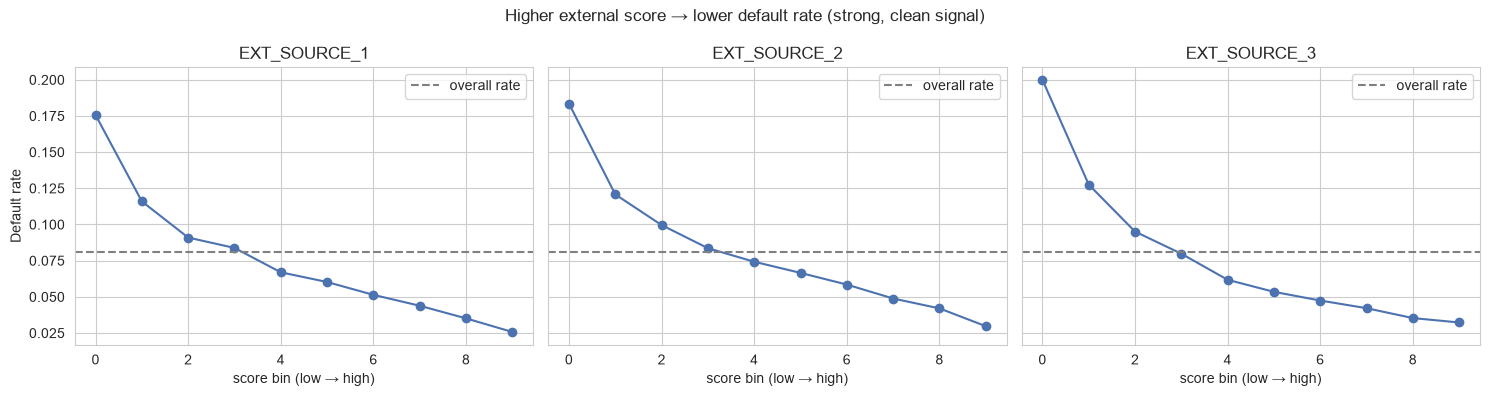

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    rates = default_rate_by_bin(app.dropna(subset=[col]), col)
    ax.plot(range(len(rates)), rates.values, marker="o", color="#4c72b0")
    ax.axhline(base_rate, color="grey", linestyle="--", label="overall rate")
    ax.set_title(col)
    ax.set_xlabel("score bin (low → high)")
    ax.legend()
axes[0].set_ylabel("Default rate")
fig.suptitle("Higher external score → lower default rate (strong, clean signal)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_ext_source_default_rate.png", dpi=120)
plt.show()

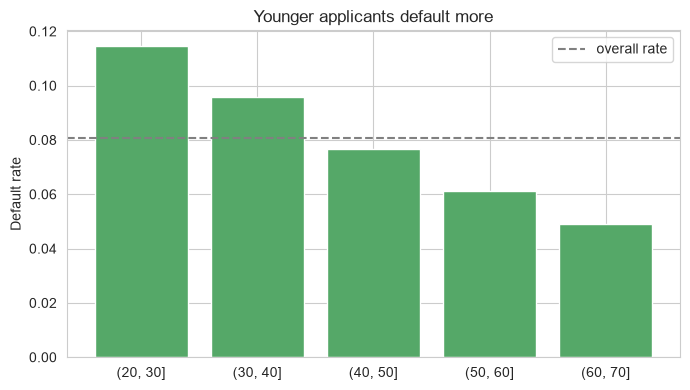

In [9]:
# Default rate by age band
age_bins = pd.cut(app["AGE_YEARS"], bins=[20, 30, 40, 50, 60, 70])
age_rate = app.groupby(age_bins, observed=True)["TARGET"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(b) for b in age_rate.index], age_rate.values, color="#55a868")
ax.axhline(base_rate, color="grey", linestyle="--", label="overall rate")
ax.set_ylabel("Default rate")
ax.set_title("Younger applicants default more")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_default_by_age.png", dpi=120)
plt.show()

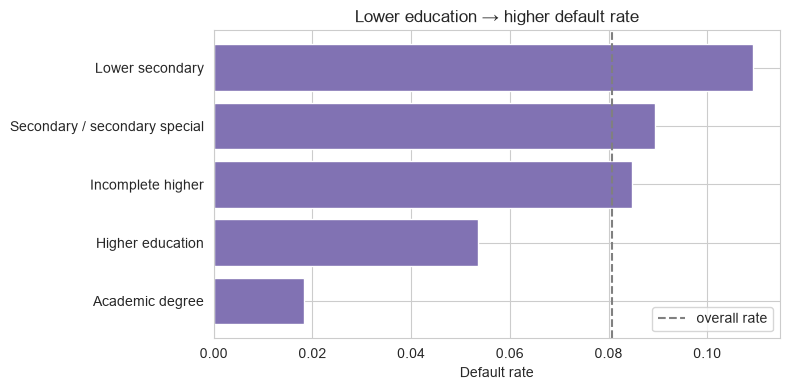

In [10]:
# Default rate by education level
edu_rate = app.groupby("NAME_EDUCATION_TYPE", observed=True)["TARGET"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(edu_rate.index, edu_rate.values, color="#8172b3")
ax.axvline(base_rate, color="grey", linestyle="--", label="overall rate")
ax.set_xlabel("Default rate")
ax.set_title("Lower education → higher default rate")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_default_by_education.png", dpi=120)
plt.show()

In [11]:
# Default rate by income band (5 equal-sized groups)
income_bins = pd.qcut(app["AMT_INCOME_TOTAL"], q=5, duplicates="drop")
income_rate = app.groupby(income_bins, observed=True)["TARGET"].mean()
print("Default rate by income group (low → high):")
print(income_rate.round(3).to_list())
print("\nIncome alone is a weak signal -- ratios like credit-to-income matter more.")

Default rate by income group (low → high):
[0.082, 0.086, 0.087, 0.081, 0.065]

Income alone is a weak signal -- ratios like credit-to-income matter more.


### Correlation of numeric features with the target

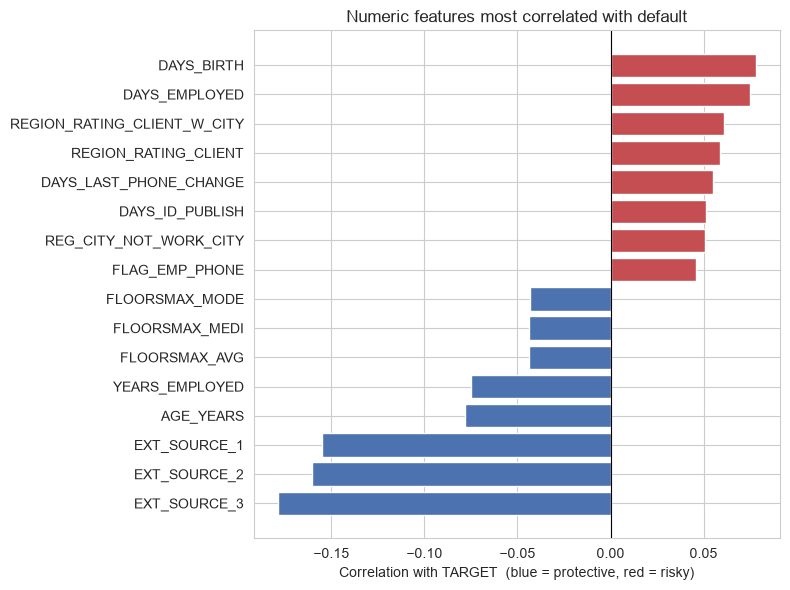

In [12]:
numeric = app.select_dtypes(include=[np.number])
corrs = numeric.corr(numeric_only=True)["TARGET"].drop("TARGET").sort_values()

top = pd.concat([corrs.head(8), corrs.tail(8)])
colors = ["#4c72b0" if v < 0 else "#c44e52" for v in top.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with TARGET  (blue = protective, red = risky)")
ax.set_title("Numeric features most correlated with default")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_target_correlations.png", dpi=120)
plt.show()

## Takeaways

- ~8% default rate → judge models on **PR-AUC**, not accuracy.
- `EXT_SOURCE_1/2/3` are the strongest signals; younger age and lower education raise risk.
- Cleaned the `DAYS_EMPLOYED` placeholder and converted `DAYS_*` to years.